In [30]:
# ============================================================
# COSC2671 Assignment 2 — M4: Run IC Simulations
# @author Melvin Abraham Mathew s4185713, RMIT University, 2026
# ============================================================

N_TRIALS       = 200
PROP_PROB      = 0.05
POSITIVE_BOOST = 0.04

print(f"Running IC simulations ({N_TRIALS} trials per condition)...")
print(f"  Base propagation probability : {PROP_PROB}")
print(f"  Positive sentiment boost     : {POSITIVE_BOOST}")
print()

results = {}

seed_strategies = {
    'High-PageRank'    : pr_seeds,
    'High-Betweenness' : bt_seeds,
    'Random'           : rnd_seeds,
}

for strategy_name, seeds in seed_strategies.items():
    print(f"  [{strategy_name}] Vanilla IC...", end=' ')
    results[f'{strategy_name}_vanilla'] = run_ic_trials(
        G_und, seeds, n_trials=N_TRIALS,
        propagation_prob=PROP_PROB
    )
    r = results[f'{strategy_name}_vanilla']
    print(f"mean activated = {r['mean_activated']:.1f} ± {r['std_activated']:.1f}")

    print(f"  [{strategy_name}] Sentiment-weighted IC...", end=' ')
    results[f'{strategy_name}_sentiment'] = run_ic_trials(
        G_und, seeds, n_trials=N_TRIALS,
        propagation_prob=PROP_PROB,
        sentiment_map=sentiment_map,
        positive_boost=POSITIVE_BOOST
    )
    r = results[f'{strategy_name}_sentiment']
    print(f"mean activated = {r['mean_activated']:.1f} ± {r['std_activated']:.1f}")
    print()

total_nodes = G_und.number_of_nodes()

print("=== Simulation Results Summary ===")
print(f"{'Condition':<35} {'Mean Activated':>15} {'Std':>8} {'Median':>8} {'Avg Steps':>10}")
print("-" * 80)
for condition, res in results.items():
    pct = res['mean_activated'] / total_nodes * 100
    print(f"  {condition:<33} {res['mean_activated']:>8.1f} ({pct:4.1f}%) "
          f"{res['std_activated']:>8.1f} "
          f"{res['median_activated']:>8.1f} "
          f"{res['mean_steps']:>10.1f}")

summary_rows = []
for condition, res in results.items():
    strategy, variant = condition.rsplit('_', 1)
    summary_rows.append({
        'condition'        : condition,
        'strategy'         : strategy,
        'variant'          : variant,
        'mean_activated'   : res['mean_activated'],
        'std_activated'    : res['std_activated'],
        'median_activated' : res['median_activated'],
        'pct_network'      : res['mean_activated'] / total_nodes * 100,
        'mean_steps'       : res['mean_steps'],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(TABLE_DIR / 'M_diffusion_summary.csv', index=False)
print("\nSaved: tables/M_diffusion_summary.csv")

Running IC simulations (200 trials per condition)...
  Base propagation probability : 0.05
  Positive sentiment boost     : 0.04

  [High-PageRank] Vanilla IC... mean activated = 68.4 ± 10.3
  [High-PageRank] Sentiment-weighted IC... mean activated = 117.2 ± 20.5

  [High-Betweenness] Vanilla IC... mean activated = 41.0 ± 10.6
  [High-Betweenness] Sentiment-weighted IC... mean activated = 61.9 ± 22.9

  [Random] Vanilla IC... mean activated = 11.1 ± 2.8
  [Random] Sentiment-weighted IC... mean activated = 10.8 ± 4.6

=== Simulation Results Summary ===
Condition                            Mean Activated      Std   Median  Avg Steps
--------------------------------------------------------------------------------
  High-PageRank_vanilla                 68.4 ( 0.3%)     10.3     68.0        3.1
  High-PageRank_sentiment              117.2 ( 0.4%)     20.5    117.0        4.3
  High-Betweenness_vanilla              41.0 ( 0.2%)     10.6     39.0        3.0
  High-Betweenness_sentiment      

## Section M5 - Diffusion Visualisations

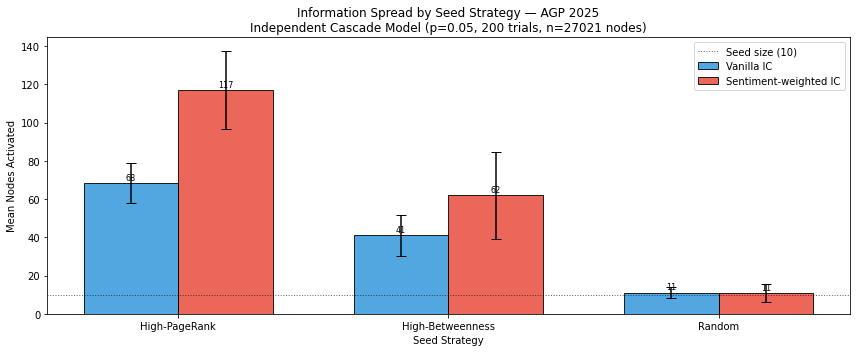

Saved: M_diffusion_comparison.png


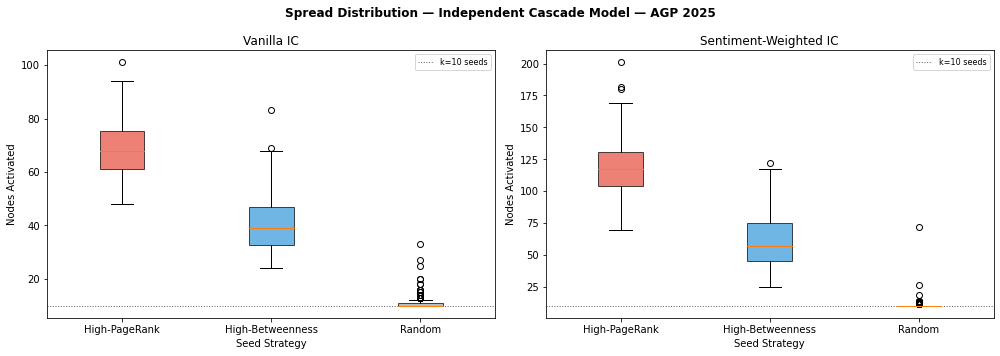

Saved: M_diffusion_boxplot.png


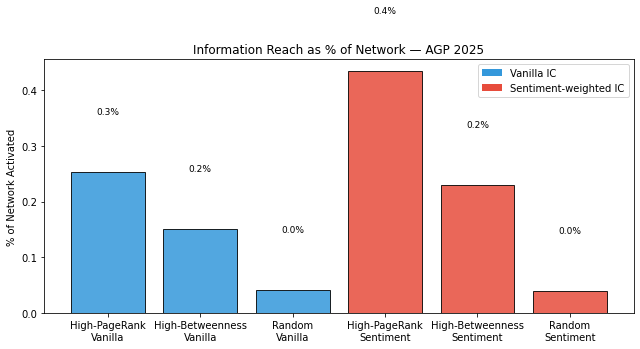

Saved: M_diffusion_pct_network.png


In [31]:
# ============================================================
# COSC2671 Assignment 2 — M5: Diffusion Visualisations
# @author Melvin Abraham Mathew s4185713, RMIT University, 2026
# ============================================================

strategies = list(seed_strategies.keys())
strategy_colors = {
    'High-PageRank'    : '#e74c3c',
    'High-Betweenness' : '#3498db',
    'Random'           : '#95a5a6',
}

vanilla_means   = [results[f'{s}_vanilla']['mean_activated']   for s in strategies]
vanilla_stds    = [results[f'{s}_vanilla']['std_activated']    for s in strategies]
sentiment_means = [results[f'{s}_sentiment']['mean_activated'] for s in strategies]
sentiment_stds  = [results[f'{s}_sentiment']['std_activated']  for s in strategies]

# ── Plot 1: Grouped bar — mean spread ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(strategies))
width = 0.35

bars1 = ax.bar(x - width/2, vanilla_means,   width, yerr=vanilla_stds,
               label='Vanilla IC',            color='#3498db', edgecolor='black',
               alpha=0.85, capsize=5)
bars2 = ax.bar(x + width/2, sentiment_means, width, yerr=sentiment_stds,
               label='Sentiment-weighted IC', color='#e74c3c', edgecolor='black',
               alpha=0.85, capsize=5)

ax.axhline(N_SEEDS, color='black', linestyle=':', alpha=0.6,
           linewidth=1, label=f'Seed size ({N_SEEDS})')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.set_xlabel('Seed Strategy')
ax.set_ylabel('Mean Nodes Activated')
ax.set_title(f'Information Spread by Seed Strategy — AGP 2025\n'
             f'Independent Cascade Model (p={PROP_PROB}, {N_TRIALS} trials, n={total_nodes} nodes)')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'M_diffusion_comparison.png', dpi=150)
plt.show()
print("Saved: M_diffusion_comparison.png")

# ── Plot 2: Box plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, variant, title in zip(
    axes,
    ['vanilla', 'sentiment'],
    ['Vanilla IC', 'Sentiment-Weighted IC']
):
    data   = [results[f'{s}_{variant}']['all_spreads'] for s in strategies]
    colors = [strategy_colors[s] for s in strategies]
    bp     = ax.boxplot(data, labels=strategies, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.axhline(N_SEEDS, color='black', linestyle=':', alpha=0.6,
               linewidth=1, label=f'k={N_SEEDS} seeds')
    ax.set_xlabel('Seed Strategy')
    ax.set_ylabel('Nodes Activated')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Spread Distribution — Independent Cascade Model — AGP 2025',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'M_diffusion_boxplot.png', dpi=150)
plt.show()
print("Saved: M_diffusion_boxplot.png")

# ── Plot 3: % of network reached ─────────────────────────────
from matplotlib.patches import Patch

conds = [f'{s}\nVanilla' for s in strategies] + [f'{s}\nSentiment' for s in strategies]
means = vanilla_means + sentiment_means
pcts  = [m / total_nodes * 100 for m in means]
bar_c = ['#3498db'] * 3 + ['#e74c3c'] * 3

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(conds, pcts, color=bar_c, edgecolor='black', alpha=0.85)
ax.set_ylabel('% of Network Activated')
ax.set_title('Information Reach as % of Network — AGP 2025')
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
ax.legend(handles=[
    Patch(facecolor='#3498db', label='Vanilla IC'),
    Patch(facecolor='#e74c3c', label='Sentiment-weighted IC'),
])
plt.tight_layout()
plt.savefig(FIG_DIR / 'M_diffusion_pct_network.png', dpi=150)
plt.show()
print("Saved: M_diffusion_pct_network.png")

## Section M6 - Sentiment Spread Analysis

Tests whether seeding from **positive** high-PageRank commenters produces different reach compared to **negative** high-PageRank commenters, and examines the sentiment profile of nodes that get activated most frequently.

Positive-sentiment high-PR seeds : 10
Negative-sentiment high-PR seeds : 10

Running positive-seed IC...
Running negative-seed IC...

=== Positive vs Negative Seed Comparison ===
  Positive-seeded spread: 134.5 ± 20.8 nodes
  Negative-seeded spread: 31.6 ± 19.0 nodes

=== Sentiment Profile of Frequently Activated Nodes ===

Positive-seeded IC — activated node sentiment:
neutral     44.145873
positive    37.619962
negative    18.234165

Negative-seeded IC — activated node sentiment:
neutral     50.000000
negative    41.666667
positive     8.333333


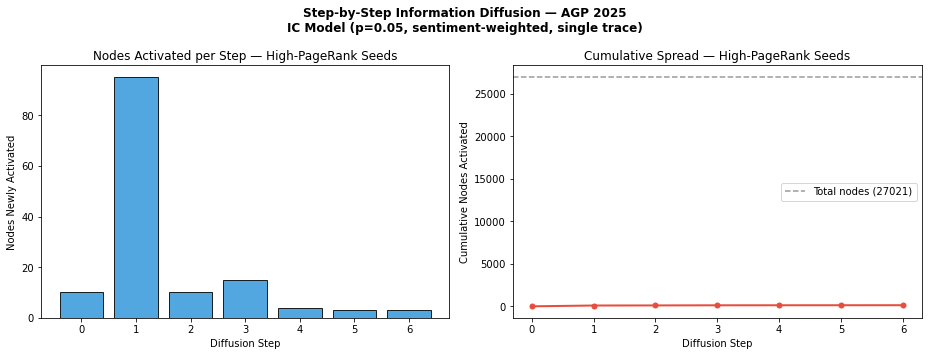

Saved: M_diffusion_stepwise.png


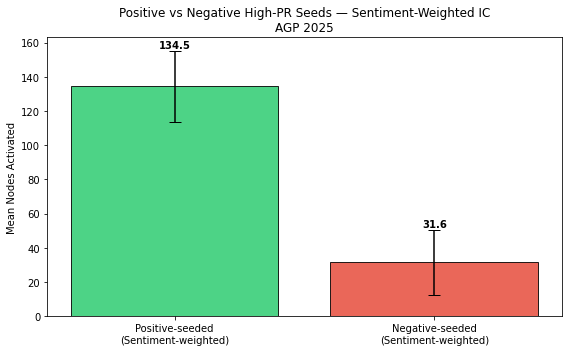

Saved: M_diffusion_pos_vs_neg.png


In [32]:
# ============================================================
# COSC2671 Assignment 2 — M6: Sentiment Spread Analysis
# @author Melvin Abraham Mathew s4185713, RMIT University, 2026
# ============================================================

positive_users = cent_df[cent_df['avg_sentiment'] >  0.05].nlargest(N_SEEDS, 'pagerank')['user_alias'].tolist()
negative_users = cent_df[cent_df['avg_sentiment'] < -0.05].nlargest(N_SEEDS, 'pagerank')['user_alias'].tolist()

pos_seeds = valid_seeds(positive_users, G_und)
neg_seeds = valid_seeds(negative_users, G_und)

print(f"Positive-sentiment high-PR seeds : {len(pos_seeds)}")
print(f"Negative-sentiment high-PR seeds : {len(neg_seeds)}")

print("\nRunning positive-seed IC...")
pos_results = run_ic_trials(G_und, pos_seeds, n_trials=N_TRIALS,
                             propagation_prob=PROP_PROB,
                             sentiment_map=sentiment_map,
                             positive_boost=POSITIVE_BOOST)

print("Running negative-seed IC...")
neg_results = run_ic_trials(G_und, neg_seeds, n_trials=N_TRIALS,
                             propagation_prob=PROP_PROB,
                             sentiment_map=sentiment_map,
                             positive_boost=POSITIVE_BOOST)

print(f"\n=== Positive vs Negative Seed Comparison ===")
print(f"  Positive-seeded spread: {pos_results['mean_activated']:.1f} ± {pos_results['std_activated']:.1f} nodes")
print(f"  Negative-seeded spread: {neg_results['mean_activated']:.1f} ± {neg_results['std_activated']:.1f} nodes")

def sentiment_profile_of_activated(freq_dict, cent_df, threshold=0.1):
    freq_series  = pd.Series(freq_dict)
    common_nodes = freq_series[freq_series >= threshold].index.tolist()
    activated_df = cent_df[cent_df['user_alias'].isin(common_nodes)]
    if len(activated_df) == 0:
        return None
    return activated_df['dominant_sentiment'].value_counts(normalize=True) * 100

print("\n=== Sentiment Profile of Frequently Activated Nodes ===")
pos_profile = sentiment_profile_of_activated(pos_results['activation_freq'], cent_df)
neg_profile = sentiment_profile_of_activated(neg_results['activation_freq'], cent_df)

if pos_profile is not None:
    print("\nPositive-seeded IC — activated node sentiment:")
    print(pos_profile.to_string())
if neg_profile is not None:
    print("\nNegative-seeded IC — activated node sentiment:")
    print(neg_profile.to_string())

# Step-by-step single trace
activated_trace, history_trace = independent_cascade(
    G_und, pr_seeds, propagation_prob=PROP_PROB,
    sentiment_map=sentiment_map, positive_boost=POSITIVE_BOOST
)

step_counts = [len(wave) for wave in history_trace]
cumulative  = np.cumsum(step_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(len(step_counts)), step_counts,
            color='#3498db', edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Diffusion Step')
axes[0].set_ylabel('Nodes Newly Activated')
axes[0].set_title('Nodes Activated per Step — High-PageRank Seeds')

axes[1].plot(range(len(cumulative)), cumulative,
             marker='o', color='#e74c3c', linewidth=2, markersize=5)
axes[1].axhline(total_nodes, color='black', linestyle='--', alpha=0.4,
                label=f'Total nodes ({total_nodes})')
axes[1].set_xlabel('Diffusion Step')
axes[1].set_ylabel('Cumulative Nodes Activated')
axes[1].set_title('Cumulative Spread — High-PageRank Seeds')
axes[1].legend()

plt.suptitle('Step-by-Step Information Diffusion — AGP 2025\n'
             f'IC Model (p={PROP_PROB}, sentiment-weighted, single trace)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'M_diffusion_stepwise.png', dpi=150)
plt.show()
print("Saved: M_diffusion_stepwise.png")

# Positive vs negative seeds bar chart
fig, ax = plt.subplots(figsize=(8, 5))
labels  = ['Positive-seeded\n(Sentiment-weighted)', 'Negative-seeded\n(Sentiment-weighted)']
means   = [pos_results['mean_activated'], neg_results['mean_activated']]
stds    = [pos_results['std_activated'],  neg_results['std_activated']]
bar_c   = ['#2ecc71', '#e74c3c']

bars = ax.bar(labels, means, yerr=stds, color=bar_c,
              edgecolor='black', alpha=0.85, capsize=6)
ax.set_ylabel('Mean Nodes Activated')
ax.set_title('Positive vs Negative High-PR Seeds — Sentiment-Weighted IC\nAGP 2025')
for bar, m, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.5,
            f'{m:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'M_diffusion_pos_vs_neg.png', dpi=150)
plt.show()
print("Saved: M_diffusion_pos_vs_neg.png")

## Section M7 - Activation Frequency Network Map

Shows which nodes get activated most often across all IC trials when seeding from high-PageRank users. Colour intensity = activation frequency.

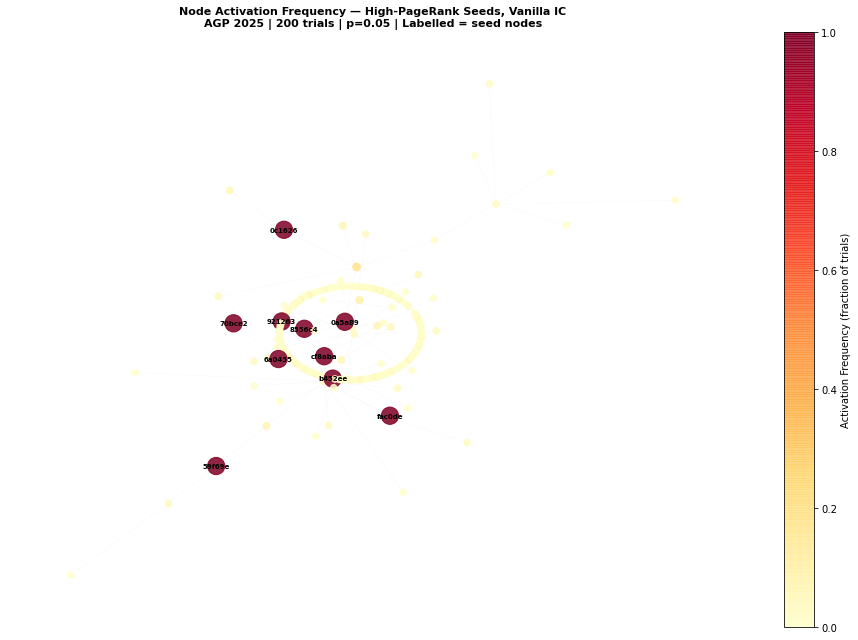

Saved: M_diffusion_activation_map.png


In [33]:
# ============================================================
# COSC2671 Assignment 2 — M7: Activation Frequency Network Viz
# @author Melvin Abraham Mathew s4185713, RMIT University, 2026
# ============================================================

top200    = cent_df.nlargest(200, 'pagerank')['user_alias'].tolist()
top200    = [n for n in top200 if G_und.has_node(n)]
H         = G_und.subgraph(top200).copy()
pos       = nx.kamada_kawai_layout(H, weight='weight')

freq_map  = results['High-PageRank_vanilla']['activation_freq']
freq_vals = np.array([freq_map.get(n, 0) for n in H.nodes()])

norm      = mcolors.Normalize(vmin=0, vmax=1)
cmap      = cm.YlOrRd
seed_set  = set(pr_seeds)
node_sizes = [300 if n in seed_set else 40 + 100 * freq_map.get(n, 0)
              for n in H.nodes()]

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_edges(H, pos, alpha=0.08, width=0.5,
                       edge_color='#aaaaaa', ax=ax)
sc = nx.draw_networkx_nodes(H, pos, node_size=node_sizes,
                             node_color=freq_vals, cmap=cmap,
                             vmin=0, vmax=1, alpha=0.85, ax=ax)

seed_labels = {n: n[-6:] for n in pr_seeds if n in H.nodes()}
nx.draw_networkx_labels(H, pos, labels=seed_labels,
                        font_size=7, font_weight='bold', ax=ax)

plt.colorbar(sc, ax=ax, label='Activation Frequency (fraction of trials)')
ax.set_title(
    'Node Activation Frequency — High-PageRank Seeds, Vanilla IC\n'
    f'AGP 2025 | {N_TRIALS} trials | p={PROP_PROB} | Labelled = seed nodes',
    fontsize=11, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'M_diffusion_activation_map.png', dpi=150)
plt.show()
print("Saved: M_diffusion_activation_map.png")

## M_Final - Summary

In [34]:
# ============================================================
# COSC2671 Assignment 2 — M: Final Summary
# @author Melvin Abraham Mathew s4185713, RMIT University, 2026
# ============================================================

print("=" * 65)
print("COSC2671 Assignment 2 — M's Diffusion Analysis Summary")
print("=" * 65)

print(f"\nMODEL SETTINGS")
print(f"  Model                    : Independent Cascade (L10)")
print(f"  Base propagation prob    : {PROP_PROB}")
print(f"  Sentiment boost          : +{POSITIVE_BOOST} for positive nodes")
print(f"  Trials per condition     : {N_TRIALS}")
print(f"  Seeds per strategy       : {N_SEEDS}")
print(f"  Total nodes in network   : {total_nodes}")

print(f"\nSEED STRATEGY RESULTS")
print(f"{'Strategy':<25} {'Vanilla':>12} {'Sentiment-W':>14} {'% Reach (V)':>12}")
print("-" * 65)
for s in strategies:
    v = results[f'{s}_vanilla']['mean_activated']
    w = results[f'{s}_sentiment']['mean_activated']
    print(f"  {s:<23} {v:>10.1f}   {w:>12.1f}   {v/total_nodes*100:>10.1f}%")

print(f"\nSENTIMENT SEED COMPARISON (Sentiment-weighted IC)")
print(f"  Positive high-PR seeds spread : {pos_results['mean_activated']:.1f} nodes")
print(f"  Negative high-PR seeds spread : {neg_results['mean_activated']:.1f} nodes")

best = max(results.items(), key=lambda x: x[1]['mean_activated'])
print(f"\nBEST CONDITION: {best[0]} — {best[1]['mean_activated']:.1f} nodes activated on average")

print("\nFIGURES SAVED")
for f in sorted(FIG_DIR.glob('M_*.png')):
    print(f"  {f.name}")

print("\nTABLES SAVED")
for t in sorted(TABLE_DIR.glob('M_*.csv')):
    print(f"  {t.name}")

COSC2671 Assignment 2 — M's Diffusion Analysis Summary

MODEL SETTINGS
  Model                    : Independent Cascade (L10)
  Base propagation prob    : 0.05
  Sentiment boost          : +0.04 for positive nodes
  Trials per condition     : 200
  Seeds per strategy       : 10
  Total nodes in network   : 27021

SEED STRATEGY RESULTS
Strategy                       Vanilla    Sentiment-W  % Reach (V)
-----------------------------------------------------------------
  High-PageRank                 68.4          117.2          0.3%
  High-Betweenness              41.0           61.9          0.2%
  Random                        11.1           10.8          0.0%

SENTIMENT SEED COMPARISON (Sentiment-weighted IC)
  Positive high-PR seeds spread : 134.5 nodes
  Negative high-PR seeds spread : 31.6 nodes

BEST CONDITION: High-PageRank_sentiment — 117.2 nodes activated on average

FIGURES SAVED
  M_diffusion_activation_map.png
  M_diffusion_boxplot.png
  M_diffusion_comparison.png
  M_diffusi

In [35]:
import shutil

shutil.make_archive('data', 'zip', 'data')


shutil.make_archive('outputs', 'zip', 'outputs')

'C:\\Users\\Lenovo\\AAAAAAAAAAAAA SMNA\\outputs.zip'